<a href="https://colab.research.google.com/github/peanutpirate/Week_7_CodeCamp_2026_Projects_And_Learning_Materials/blob/Projects_Daily/17_EndToEnd_CarPrice_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 End-to-End Car Price Intelligence System

## Projenin Amacı

Bu proje Mercedes ikinci el araç verisini analiz ederek araç fiyatlarını
tahmin eden bir makine öğrenmesi modeli geliştirmeyi amaçlamaktadır.

Ancak model kurmadan önce veri analiz edilmelidir.

Bu nedenle proje şu aşamaları içerir:

1. Veriyi anlamak
2. Grafiksel analizler
3. En pahalı araçların analizi
4. Veri temizliği
5. Feature ve target hazırlığı
6. TensorFlow modeli oluşturma
7. Model eğitimi
8. Model performans değerlendirmesi

Amaç yalnızca model kurmak değil,
veriye güvenip güvenemeyeceğimizi anlamaktır.

In [ ]:
"""
Hücre 2 – Veriyi Anlamak (8.15)
- `head()`, `info()`, `describe()`
- Değişkenlerin anlamı
- Sayısal vs kategorik ayrımı
📌 Amaç: Modelden **önce veri*
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

df = pd.read_excel("merc.xlsx")

df.head()


,year,price,transmission,mileage,tax,mpg,engineSize
0,2005,5200,Automatic,63000,325,32.1,1.8
1,2017,34948,Automatic,27000,20,61.4,2.1
2,2016,49948,Automatic,6200,555,28.0,5.5
3,2016,61948,Automatic,16000,325,30.4,4.0
4,2016,73948,Automatic,4000,325,30.1,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13119 entries, 0 to 13118
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13119 non-null  int64  
 1   price         13119 non-null  int64  
 2   transmission  13119 non-null  object 
 3   mileage       13119 non-null  int64  
 4   tax           13119 non-null  int64  
 5   mpg           13119 non-null  float64
 6   engineSize    13119 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 717.6+ KB


In [ ]:
df.describe()


,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [ ]:
## Veri Seti Özeti

# Veri setinde şu değişkenler bulunmaktadır:

# - year → araç modeli yılı
# - price → araç fiyatı
# - transmission → şanzıman türü
# - mileage → aracın kilometresi
# - tax → araç vergisi
# - mpg → yakıt verimliliği
# - engineSize → motor hacmi

# Sayısal değişkenler:

# year, price, mileage, tax, mpg, engineSize

# Kategorik değişken:

# transmission

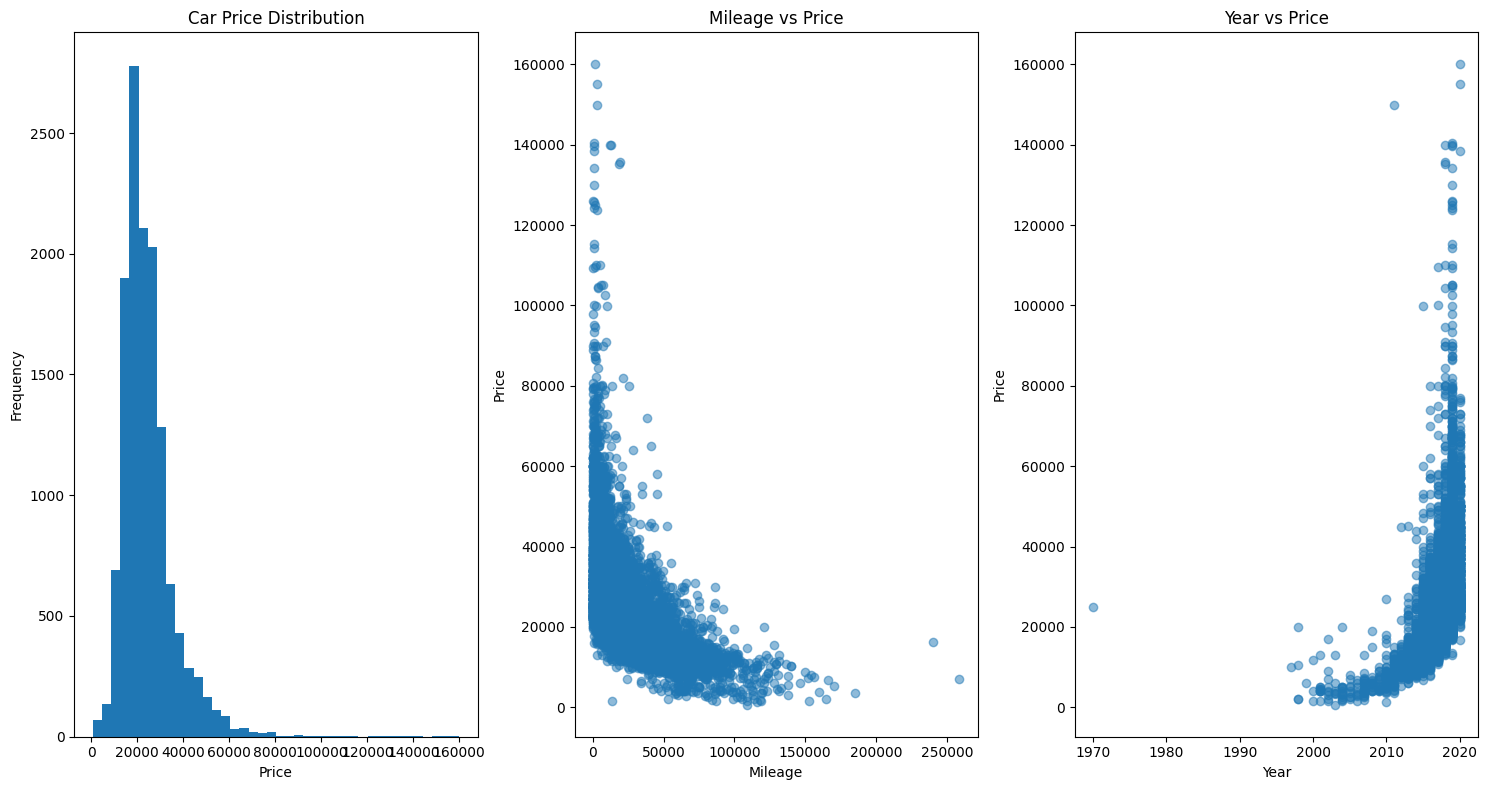

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

# Fiyat Dağılımı (histogram)
plt.subplot(1,3,1)
plt.hist(df["price"], bins=40)
plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

# Kilometre vs. Fiyat (scatter)
plt.subplot(1,3,2)
plt.scatter(df["mileage"], df["price"], alpha=0.5)
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")

# Yıl vs fiyat (line/ scatter)
plt.subplot(1,3,3)
plt.scatter(df["year"], df["price"], alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price")

plt.tight_layout()
plt.show()

In [ ]:
"""
### Hücre 4 – En Yüksek Fiyatlı Arabalar (8.17)
- En pahalı 10 aracı bul
- Bu araçların ortak özelliklerini yorumla
📌 Markdown yorum **zorunlu**
"""
top_cars = df.sort_values("price", ascending=False).head(10)

top_cars

,year,price,transmission,mileage,tax,mpg,engineSize
6199,2020,159999,Semi-Auto,1350,145,21.4,4.0
10044,2020,154998,Automatic,3000,150,21.4,4.0
5,2011,149948,Automatic,3000,570,21.4,6.2
8737,2019,140319,Semi-Auto,785,150,22.1,4.0
6386,2018,139995,Semi-Auto,13046,145,21.4,4.0
8,2019,139948,Automatic,12000,145,21.4,4.0
9133,2019,139559,Semi-Auto,1000,145,22.1,4.0
8821,2020,138439,Semi-Auto,1000,145,22.1,4.0
5902,2018,135771,Semi-Auto,19000,145,21.4,4.0
7864,2018,135124,Semi-Auto,18234,150,21.4,4.0


In [ ]:
## En Pahalı Araçların Analizi

# En pahalı araçlar incelendiğinde şu özellikler dikkat çekmektedir:

# - Yeni model yılları
# - Büyük motor hacmi
# - Düşük kilometre

# Bu özellikler araç fiyatını artıran faktörlerdir.

# Bu durum veri setinin genel piyasa mantığıyla uyumlu olduğunu göstermektedir.

In [ ]:
"""
### 🟦 Hücre 5 – Veri Temizliği (8.18)
- Eksik değerler
- Uç değerler
- Mantıksız kayıtlar
📌 Neyi neden sildiğini **açıkla**
"""
# Eksik Değerler
df.isnull().sum()

,0
year,0
price,0
transmission,0
mileage,0
tax,0
mpg,0
engineSize,0


In [ ]:
# Mantıksız Değerler
df = df[df["price"] > 0]

In [ ]:
# Uç değerler
upper_limit = df["price"].quantile(0.99)

df = df[df["price"] < upper_limit]

In [ ]:
df = df.drop("transmission",axis=1)

In [ ]:
print("Cleaned DataFrame Head:")
print(df.head())
print("\nCleaned DataFrame Info:")
df.info()

Cleaned DataFrame Head:
   year  price  mileage  tax   mpg  engineSize
0  2005   5200    63000  325  32.1         1.8
1  2017  34948    27000   20  61.4         2.1
2  2016  49948     6200  555  28.0         5.5
3  2016  61948    16000  325  30.4         4.0
4  2016  73948     4000  325  30.1         4.0

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13119 entries, 0 to 13118
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        13119 non-null  int64  
 1   price       13119 non-null  int64  
 2   mileage     13119 non-null  int64  
 3   tax         13119 non-null  int64  
 4   mpg         13119 non-null  float64
 5   engineSize  13119 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 615.1 KB


In [ ]:
# Veri temizliği sırasında:

# - negatif fiyatlar kaldırıldı
# - aşırı yüksek fiyatlar filtrelendi
# - Transmission silindi.

# Bu işlemler modelin daha stabil öğrenmesini sağlar.

In [ ]:
"""
### Hücre 6 – Feature & Target Hazırlığı
- X (özellikler)
- y (fiyat)
- Basit ölçekleme / normalizasyon
📌 Model için uygun hale getirme
"""
X = df.drop("price", axis=1).values
y = df["price"].values

In [ ]:
X = (X - X.mean()) / X.std()

In [ ]:
"""
### Hücre 7 – Model Oluşturmak (8.19)
- `Sequential` model
- Dense katmanlar
- Regresyon çıkışı
📌 “Neden bu yapı?” kısa açıklama
"""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = tf.keras.Sequential([

    tf.keras.layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1)

])


In [ ]:
# Model iki hidden layer içermektedir.

# ReLU aktivasyonu doğrusal olmayan ilişkileri öğrenmeye yardımcı olur.

# Output layer aktivasyonsuzdur çünkü problem bir **regresyon problemidir**.

In [ ]:
"""
### Hücre 8 – Model Eğitimi
- Train / test ayrımı
- `fit()`
- Epoch – batch ayarı
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 672460800.0000 - mae: 23968.7148 - val_loss: 679351424.0000 - val_mae: 24110.4395
Epoch 2/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 638842176.0000 - mae: 23278.4746 - val_loss: 613264384.0000 - val_mae: 22525.3047
Epoch 3/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 542102976.0000 - mae: 20962.9121 - val_loss: 478297056.0000 - val_mae: 18926.3516
Epoch 4/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 420700512.0000 - mae: 17444.8359 - val_loss: 344937728.0000 - val_mae: 15105.0078
Epoch 5/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 301867872.0000 - mae: 13833.8057 - val_loss: 261859824.0000 - val_mae: 12687.3408
Epoch 6/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 234106912.0000 - mae: 11805.6572 - val_loss: 203447760.0000 - val_mae: 10935.9355
Epoch 7/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 185150448.0000 - mae: 10277.9805 - val_loss: 158648064.0000 - val_mae: 9510.2373
Epoch 8

In [ ]:
"""
### Hücre 9 – Sonuçları Değerlendirmek (8.20)
- Test set performansı
- MAE / MSE yorum
- Model nerede iyi / kötü?
"""
# Model Değerlendirme
loss, mae = model.evaluate(X_test, y_test)

print("Test MSE:", loss)
print("Test MAE:", mae)

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58702252.0000 - mae: 5537.0298
Test MSE: 58942104.0
Test MAE: 5563.6142578125


---
> Model test verisi üzerinde değerlendirilmiştir.

> MAE değeri modelin ortalama tahmin hatasını göstermektedir.

> Model özellikle orta fiyatlı araçlarda daha doğru tahminler yapabilir.

> Ancak çok pahalı araçlarda hata oranı artabilir.
---

# Yönetici Özeti
---

> Araç fiyatı en çok şu faktörlerden etkilenmektedir:
   - model yılı
   - kilometre
   - motor hacmi

> Model genel olarak orta segment araç fiyatlarını başarılı şekilde tahmin etmektedir.

> Çok yüksek fiyatlı araçlarda tahmin hatası artmaktadır.

> Daha fazla veri ve ek özellikler ile model performansı artırılabilir.

> Bu sistem ikinci el araç fiyatlandırma sistemlerinde kullanılabilir.